# Transfer Learning using VGG16 Model

We will use the VGG-16 network architecture but we instantiate the convolutional base of the network with weights that have been pre-trained on the ImageNet dataset. We will add our own classification layer and only train that portion of the network on the **types of balls** dataset to demonstrate that using a pre-trained convolutional base can be an effective approach for adapting a network to a new problem type. This technique is called **transfer learning**.

<img src='https://opencv.org/wp-content/uploads/2022/03/c4_03_cnn_vgg_pretrained_base_balls.png' width=1000 align='center'><br/>

In [34]:
from dataclasses import dataclass
import numpy as np

import tensorflow as tf
import keras
from keras import layers
from keras.utils import image_dataset_from_directory

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

### Dataset and Training Configurations

In [2]:
@dataclass(frozen=True)
class DatasetConfig:
    IMG_HEIGHT: int = 224
    IMG_WIDTH: int = 224
    NUM_CHANNELS: int = 3
    NUM_CLASSES: int = 10
    BATCH_SIZE: int = 32
    DATA_ROOT_TRAIN: str = "../dataset/train"
    DATA_ROOT_VALID: str = "./../dataset/valid"


@dataclass(frozen=True)
class TrainingConfig:
    EPOCHS: int = 21
    LEARNING_RATE: int = 0.0001
    CHECKPOINT_FILEPATH: str = "./classification_vgg16_transfer_learning.keras"

### VGG-16 Convolution Base

The model may be loaded with pre-trained weights from ImageNet or initialized to random values. In this notebook, we will initialize with pre-trained weights.

In [5]:
inputShape = (
    DatasetConfig.IMG_HEIGHT,
    DatasetConfig.IMG_WIDTH,
    DatasetConfig.NUM_CHANNELS,
)

print("Building VGG16 model from scratch with pre-trained weights...")
convBase = keras.applications.vgg16.VGG16(
    include_top=False, weights="imagenet", input_shape=inputShape
)
convBase.trainable = False
print(convBase.summary())

Building VGG16 model from scratch with pre-trained weights...


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

None


### VGG-16 Dense Head

Add one fully-connected dense layer with 256 nodes followed by an output layer with 10 nodes. 

In [7]:
inputs = keras.Input(shape=inputShape)

x = keras.applications.vgg16.preprocess_input(inputs)
x = convBase(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
outputs = layers.Dense(DatasetConfig.NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 25088)     │          0 │ vgg16[1][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │  6,422,784 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10)        │      2,570 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,140,042 (80.64 MB)

 Trainable params: 6,425,354 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

None


### Prepare the datasets

In [9]:
SEED = 42
trainDataset = image_dataset_from_directory(
    directory=DatasetConfig.DATA_ROOT_TRAIN,
    label_mode="categorical",
    batch_size=DatasetConfig.BATCH_SIZE,
    image_size=inputShape[:2],
    seed=SEED,
)
validDataset = image_dataset_from_directory(
    directory=DatasetConfig.DATA_ROOT_VALID,
    label_mode="categorical",
    batch_size=DatasetConfig.BATCH_SIZE,
    image_size=inputShape[:2],
    seed=SEED,
)

Found 1125 files belonging to 10 classes.
Found 200 files belonging to 10 classes.


### Display sample images

In [11]:
classNames = trainDataset.class_names
print(classNames)

['baseball', 'basketball', 'beachballs', 'billiard ball', 'bowling ball', 'brass', 'buckeyballs', 'cannon ball', 'cricket ball', 'eyeballs']


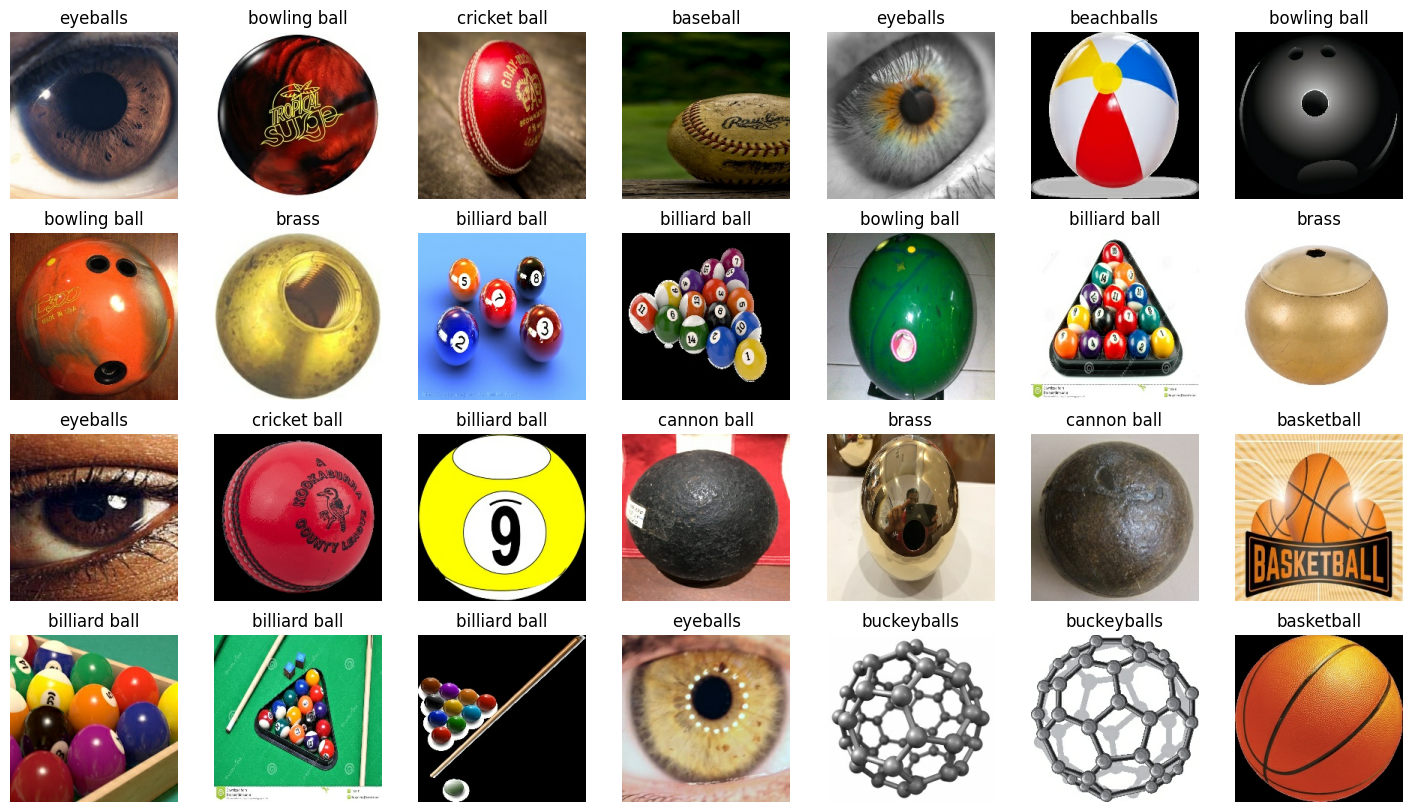

In [14]:
numRows = 4
numCols = 7

plt.figure(figsize=(18, 10))
for imagesBatch, labelsBatch in trainDataset.take(1):
    for i in range(numRows * numCols):
        ax = plt.subplot(numRows, numCols, i + 1)

        plt.imshow(imagesBatch[i].numpy().astype("uint8"))
        truthIndex = np.nonzero(labelsBatch[i].numpy())
        plt.title(classNames[truthIndex[0][0]])
        plt.axis("off")

plt.show()
plt.close()

### Base Model Evaluation before final tuning

Compile and evaluate the model before the dense classifier is trained.

In [15]:
model.compile(
    keras.optimizers.Adam(learning_rate=TrainingConfig.LEARNING_RATE),
    keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"],
)

modelCheckpointCallback = keras.callbacks.ModelCheckpoint(
    filepath=TrainingConfig.CHECKPOINT_FILEPATH,
    save_best_only=True,
    monitor="val_accuracy",
    mode="max",
    save_weights_only=False,
)

In [18]:
print(
    f"Model accuracy before final training: {model.evaluate(validDataset)[1] * 100:.3f}"
)

7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.1250 - loss: 22.0191
Model accuracy before final training: 12.500


### Training

In [23]:
trainingResults = model.fit(
    trainDataset,
    callbacks=modelCheckpointCallback,
    validation_data=validDataset,
    epochs=TrainingConfig.EPOCHS,
)

Epoch 1/21
36/36 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 1.0000 - loss: 1.4564e-06 - val_accuracy: 0.9300 - val_loss: 0.8148
Epoch 2/21
36/36 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 1.0000 - loss: 1.3894e-06 - val_accuracy: 0.9300 - val_loss: 0.8143
Epoch 3/21
36/36 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 1.0000 - loss: 1.3131e-06 - val_accuracy: 0.9300 - val_loss: 0.8139
Epoch 4/21
36/36 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 1.0000 - loss: 1.2493e-06 - val_accuracy: 0.9300 - val_loss: 0.8134
Epoch 5/21
36/36 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 1.0000 - loss: 1.1919e-06 - val_accuracy: 0.9300 - val_loss: 0.8129
Epoch 6/21
36/36 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 1.0000 - loss: 1.1386e-06 - val_accuracy: 0.9300 - val_loss: 0.8125
Epoch 7/21
36/36 ━━━━━━━━━━━━━━━━━━━━ 134s 4s/step - accuracy: 1.0000 - loss: 1.0925e-06 - val_accuracy: 0.9300 - val_loss: 0.8121
Epoch 8/21
36/36 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - accuracy: 1.0000 - loss: 1.0377e-06 

### Plot the metrics

In [27]:
from ast import Mult
from pickle import TRUE


def plotMetrics(metrics, metricsName=None, colours=None, yLabel=None, yLim=None):
    if not (isinstance(metrics, list) or isinstance(metrics, tuple)):
        metrics = [
            metrics,
        ]
        metricsName = [
            metricsName,
        ]
        colours = [
            colours,
        ]

    plt.figure(figsize=(15, 4))

    for index, metric in enumerate(metrics):
        plt.plot(metric, color=colours[index], label=metricsName[index])

    plt.xlabel("Epochs")
    plt.xlim([0, TrainingConfig.EPOCHS - 1])
    plt.ylabel(yLabel)
    plt.ylim(yLim)
    plt.grid(True)
    plt.legend()
    plt.show(block=False)

    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%d"))
    ax.xaxis.set_minor_locator(MultipleLocator(1))

    plt.close()

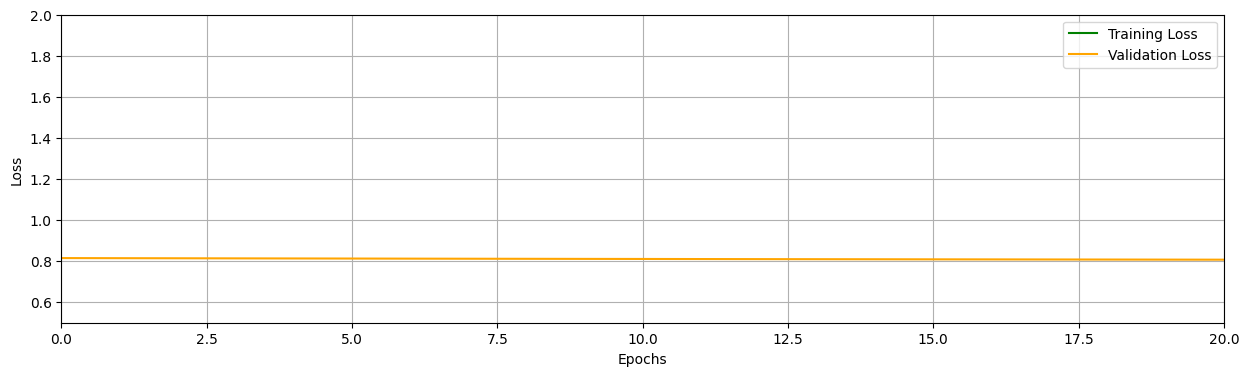

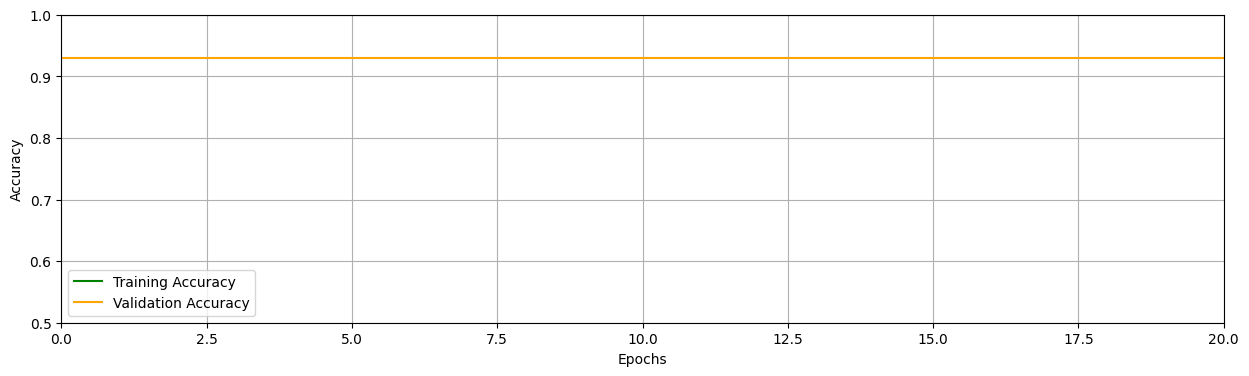

In [29]:
loss = trainingResults.history["loss"]
accuracy = trainingResults.history["accuracy"]
valid_loss = trainingResults.history["val_loss"]
valid_accuracy = trainingResults.history["val_accuracy"]

plotMetrics(
    [loss, valid_loss],
    ["Training Loss", "Validation Loss"],
    ["green", "orange"],
    "Loss",
    # [0.5, max(max(loss), max(valid_loss))],
    [0.5, 2.0],
)
plotMetrics(
    [accuracy, valid_accuracy],
    ["Training Accuracy", "Validation Accuracy"],
    ["green", "orange"],
    "Accuracy",
    [0.5, 1.0],
)

### Model Evaluation

In [31]:
savedModel = keras.models.load_model(TrainingConfig.CHECKPOINT_FILEPATH)
print(f"Model evaluation accuracy: {model.evaluate(validDataset)[1]*100.:.3f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9300 - loss: 0.8070
Model evaluation accuracy: 93.000


In [32]:
def display_wrong_predictions(model, dataset):
    plt.figure(figsize=(20, 15))
    num_rows = 4
    num_cols = 6
    jdx = 0

    # Evaluate all the batches.
    for image_batch, labels_batch in dataset:

        # Predictions for the current batch.
        predictions = model.predict(image_batch)

        # Loop over all the images in the current batch.
        for idx in range(len(labels_batch)):

            pred_idx = tf.argmax(predictions[idx]).numpy()
            truth_idx = np.nonzero(labels_batch[idx].numpy())

            # Plot the images with incorrect predictions
            if pred_idx != truth_idx:

                jdx += 1

                if jdx > num_rows * num_cols:
                    # Break from the loops if the maximum number of images have been plotted
                    break

                ax = plt.subplot(num_rows, num_cols, jdx)
                title = (
                    str(classNames[truth_idx[0][0]]) + " : " + str(classNames[pred_idx])
                )
                title_obj = plt.title(title)
                plt.setp(title_obj, color="r")
                plt.axis("off")
                plt.imshow(image_batch[idx].numpy().astype("uint8"))
    return

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step


2025-11-29 18:24:40.656489: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


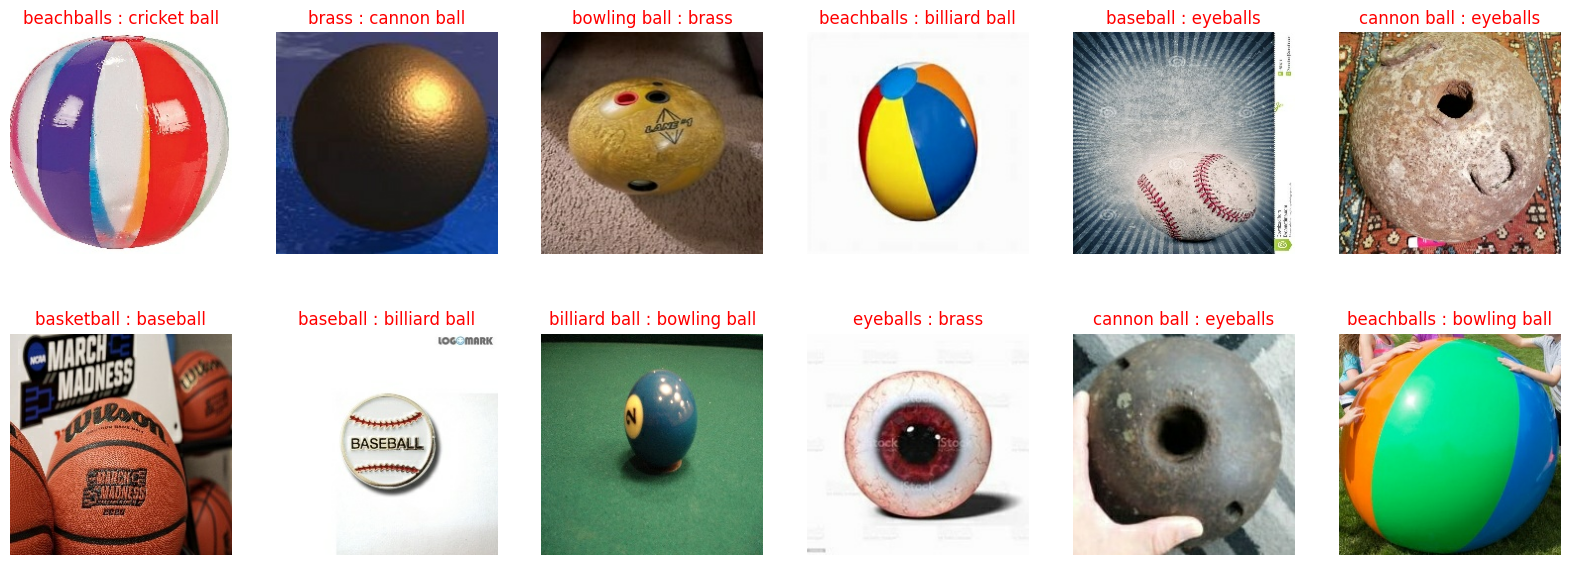

In [33]:
display_wrong_predictions(savedModel, validDataset)